In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

backend = BasicSimulator()

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.


## Quantum Random Number Generator

We generate random bits by putting a qubit into the $|+\rangle$ state (using a Hadamard gate) and measuring it. This provides a true 50/50 probability, satisfying the requirement to use quantum randomness instead of Python's `random` library.

In [3]:
def quantum_random_bits(n):
    """Generates n random bits using quantum measurement of the |+> state."""
    bits = []
    for _ in range(n):
        qc = QuantumCircuit(1, 1)
        qc.h(0)
        qc.measure(0, 0)
        t_qc = transpile(qc, backend)
        result = backend.run(t_qc, shots=1).result()
        bits.append(int(list(result.get_counts().keys())[0]))
    return bits

## Alice's Part

Alice's first 10 generated bits:  [1, 1, 0, 1, 0, 0, 0, 0, 1, 0]
Alice's first 10 generated bases: [0, 1, 0, 0, 0, 0, 0, 1, 1, 0]
Alice prepared 40 qubits.
Example Circuit for Qubit 0 (Bit: 1, Basis: 0):


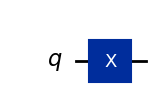

In [ ]:
NUM_QUBITS = 40
alice_bits = quantum_random_bits(NUM_QUBITS)
alice_bases = quantum_random_bits(NUM_QUBITS)

print(f"Alice's first 10 generated bits:  {alice_bits[:10]}")
print(f"Alice's first 10 generated bases: {alice_bases[:10]}")

def alice_prepare_qubit(bit, basis):
    """Prepare a single BB84 qubit using Z (0) or X (1) basis."""
    qc = QuantumCircuit(1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

alice_qubits = []
print(f"Preparing {NUM_QUBITS} qubits for Bob...")
for i in range(NUM_QUBITS):
    qc = alice_prepare_qubit(alice_bits[i], alice_bases[i])
    alice_qubits.append(qc)

print("\n--- Alice's Preparation ---")
print(f"First 10 prepared bits:  {alice_bits[:10]}")
print(f"First 10 bases used:     {alice_bases[:10]}")
print(f"Example basis for qubit 0: {'X (Diagonal)' if alice_bases[0] == 1 else 'Z (Computational)'}")

print("\nDisplaying Alice's circuit for qubit 0:")
display(alice_qubits[0].draw('mpl'))

## Bob's Part

Bob's first 10 generated bases: [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]
Simulating Bob's measurement of 40 qubits...

--- Bob's Results ---
First 10 bits measured: [1, 1, 0, 1, 1, 0, 0, 0, 1, 0]
Example basis for qubit 0: Z (Computational)

Displaying Bob's circuit for qubit 0:


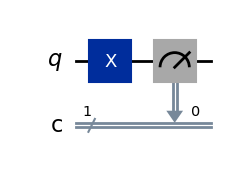

In [5]:
bob_bases = quantum_random_bits(NUM_QUBITS)
print(f"Bob's first 10 generated bases: {bob_bases[:10]}")

def measure_qubit(qubit_circuit, basis, backend):
    """Measure a qubit in Z (0) or X (1) basis and return (bit, circuit)."""
    qc = qubit_circuit.copy()
    if basis == 1:
        qc.h(0)
    c_reg = ClassicalRegister(1, 'c')
    qc.add_register(c_reg)
    qc.measure(0, 0)
    t_qc = transpile(qc, backend)
    result = backend.run(t_qc, shots=1).result()
    counts = result.get_counts()
    measured_bit = int(list(counts.keys())[0])
    return measured_bit, qc

bob_bits = []
bob_example_qc = None

print(f"Simulating Bob's measurement of {NUM_QUBITS} qubits...")
for i in range(NUM_QUBITS):
    bit, circuit = measure_qubit(alice_qubits[i], bob_bases[i], backend)
    bob_bits.append(bit)
    if i == 0:
        bob_example_qc = circuit

print("\n--- Bob's Results ---")
print(f"First 10 bits measured: {bob_bits[:10]}")
print(f"Example basis for qubit 0: {'X (Diagonal)' if bob_bases[0] == 1 else 'Z (Computational)'}")
print("\nDisplaying Bob's circuit for qubit 0:")
display(bob_example_qc.draw('mpl'))

## Sifting
Sifting and QBER are classical post-processing steps using Alice and Bob's measured bits.

In [6]:
matching_indices = [i for i in range(NUM_QUBITS) if alice_bases[i] == bob_bases[i]]
alice_key = [alice_bits[i] for i in matching_indices]
bob_key = [bob_bits[i] for i in matching_indices]

error_count = sum(1 for i in range(len(alice_key)) if alice_key[i] != bob_key[i])
qber = error_count / len(alice_key) if len(alice_key) > 0 else 0

print(f"Sifted Key Length: {len(alice_key)}")
print(f"Quantum Bit Error Rate (QBER): {qber:.2%}")
print(f"Keys match: {alice_key == bob_key}")

Sifted Key Length: 17
Quantum Bit Error Rate (QBER): 0.00%
Keys match: True
